# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 25 - 3er bimestre 2026

## **Alumno 1:** Ignacio Rubiolo

## **Alumno 2:** Lourdes Tolotto

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Pregunta 1


## 1. A


### Datos sintéticos


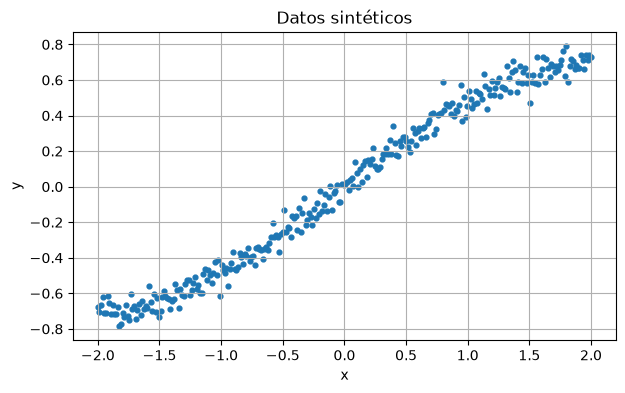

In [2]:
n = 300
x = np.linspace(-2, 2, n)

ruido = 0.05 * np.random.randn(n)
y = 0.6 * np.sin(0.8 * x) + 0.05 * x + ruido

plt.figure(figsize=(7, 4))
plt.scatter(x, y, s=12)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos sintéticos")
plt.grid(True)
plt.show()

### Funciones implementadas

Para entrenar el modelo se definieron cuatro funciones:

- `modelo()`: calcula la salida \(	anh(wx+b)\).
- `costo()`: mide el error cuadrático medio entre los valores reales y predichos.
- `gradientes()`: calcula las derivadas respecto de \(w\) y \(b\).
- `entrenar_gd()`: actualiza los parámetros durante la cantidad de épocas indicada.

Se mantuvieron separadas para que el proceso de entrenamiento quedara más claro y para poder reutilizarlas en los puntos siguientes.


In [3]:
# Calculo del forward pass, costo y gradientes

def modelo(x, w, b):
    # Funcion de activación: tanh
    return np.tanh(w * x + b)  

# Calculo del costo (MSE) a partir de las predicciones y los valores reales
def costo(y_pred, y):
    return np.mean((y_pred - y) ** 2)

# Calculo de los gradientes mediante backpropagation para actualizar los pesos y el sesgo
# "Cuanto deberian cambiar los pesos y el sesgo para reducir el costo"
def gradientes(x, y, y_pred):
    error = y_pred - y
    deriv_tanh = 1 - y_pred**2

    dw = np.mean(2 * error * deriv_tanh * x)
    db = np.mean(2 * error * deriv_tanh)

    return dw, db

# Entrenamiento del modelo mediante descenso de gradiente
# La epocas definen cuantas veces se actualizan los pesos y el sesgo
# El learning rate define cuanto cambian los pesos y el sesgo en cada actualizacion
# w0 y b0 son los valores iniciales de los pesos y el sesgo
# En historial se guardan los valores del costo en cada epoca para poder graficarlos posteriormente
def entrenar_gd(x, y, lr, epocas, w0, b0):
    w = w0
    b = b0
    historial = []

    for _ in range(epocas):
        y_pred = modelo(x, w, b)
        j = costo(y_pred, y)
        historial.append(j)

        dw, db = gradientes(x, y, y_pred)

        w -= lr * dw
        b -= lr * db

    return w, b, historial

### Entrenamiento

Se entrenó el modelo con Gradiente Descendente usando tres learning rates: `0.1`, `0.01` y `0.001`. Los tres casos parten de los mismos valores iniciales de \(w\) y \(b\), de modo que las diferencias observadas se deben al tamaño del paso y no a una inicialización distinta.

Para cada prueba se guardan los parámetros finales y el costo de cada época.


In [4]:
epocas = 100
learning_rates = [0.1, 0.01, 0.001]

np.random.seed(123)
w0 = np.random.randn()
b0 = np.random.randn()

print("Valores iniciales")
print("w:", round(w0, 4))
print("b:", round(b0, 4))

# Dentro del bucle se entrena el modelo para cada learning rate y se guardan los resultados en un diccionario
# Se guardan los pesos finales, el sesgo final y el historial de costos para cada learning rate
resultados = {}

# recorre cada learning rate y entrena el modelo con ese valor
for lr in learning_rates:
    w, b, hist = entrenar_gd(x, y, lr, epocas, w0, b0)

    resultados[lr] = {
        "w": w,
        "b": b,
        "hist": hist
    }

    print(f"\nlr = {lr}")
    print("w final:", round(w, 4))
    print("b final:", round(b, 4))
    print("costo final:", round(hist[-1], 6))

Valores iniciales
w: -1.0856
b: 0.9973

lr = 0.1
w final: 0.5039
b final: 0.0005
costo final: 0.002813

lr = 0.01
w final: -0.5176
b final: 1.0715
costo final: 1.040556

lr = 0.001
w final: -1.0215
b final: 1.0194
costo final: 1.342437


### Resultados


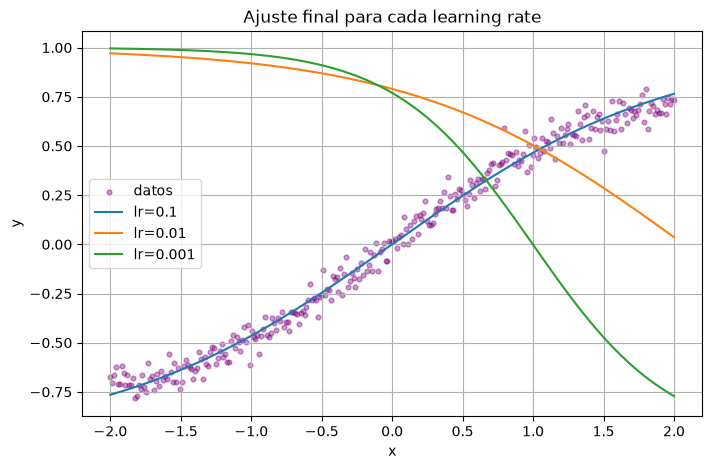

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=12, label="datos", alpha=0.4, color="purple")

for lr in learning_rates:
    w = resultados[lr]["w"]
    b = resultados[lr]["b"]
    y_pred = modelo(x, w, b)
    plt.plot(x, y_pred, label=f"lr={lr}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajuste final para cada learning rate")
plt.legend()
plt.grid(True)
plt.show()

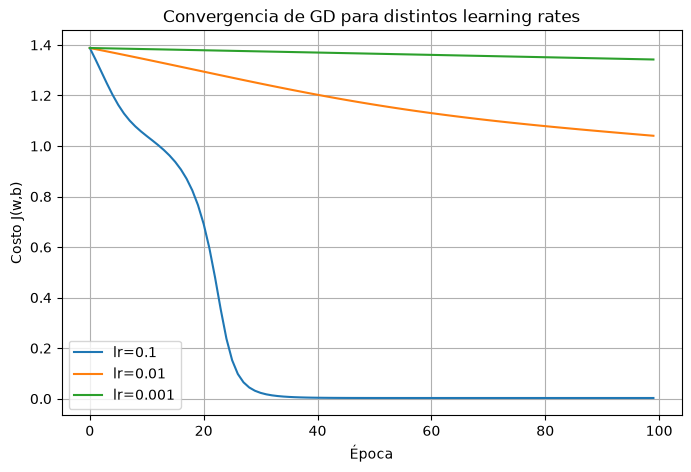

In [6]:
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    plt.plot(resultados[lr]["hist"], label=f"lr={lr}")

plt.xlabel("Época")
plt.ylabel("Costo J(w,b)")
plt.title("Convergencia de GD para distintos learning rates")
plt.legend()
plt.grid(True)
plt.show()

### Prueba extra con otros datos


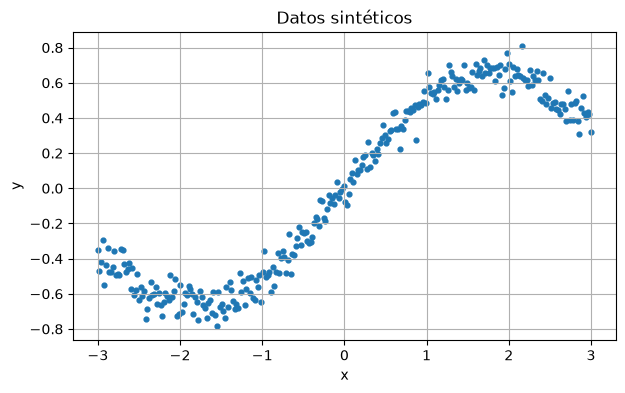

In [7]:
x_extra = np.linspace(-3, 3, n)

ruido_extra = 0.06 * np.random.randn(n)
y_extra = 0.5 * np.sin(x_extra) + 0.1 * x_extra + ruido_extra

plt.figure(figsize=(7, 4))
plt.scatter(x_extra, y_extra, s=12)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos sintéticos")
plt.grid(True)
plt.show()

In [8]:
print("Valores iniciales")
print("w:", round(w0, 4))
print("b:", round(b0, 4))

# Dentro del bucle se entrena el modelo para cada learning rate y se guardan los resultados en un diccionario
# Se guardan los pesos finales, el sesgo final y el historial de costos para cada learning rate
resultados_extra = {}

# recorre cada learning rate y entrena el modelo con ese valor
for lr in learning_rates:
    w, b, hist = entrenar_gd(x_extra, y_extra, lr, epocas, w0, b0)

    resultados_extra[lr] = {
        "w": w,
        "b": b,
        "hist": hist
    }

    print(f"\nlr = {lr}")
    print("w final:", round(w, 4))
    print("b final:", round(b, 4))
    print("costo final:", round(hist[-1], 6))

Valores iniciales
w: -1.0856
b: 0.9973

lr = 0.1
w final: 0.3555
b final: -0.0016
costo final: 0.031863

lr = 0.01
w final: -0.3421
b final: 1.1481
costo final: 1.062645

lr = 0.001
w final: -1.0235
b final: 1.0203
costo final: 1.636551


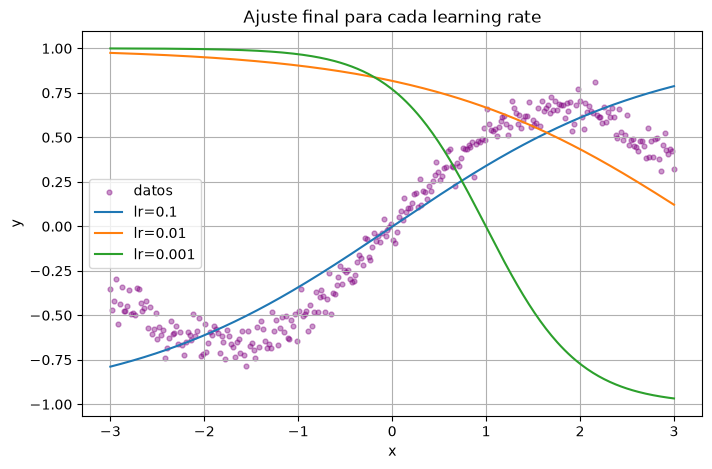

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(x_extra, y_extra, s=12, label="datos", alpha=0.4, color="purple")

for lr in learning_rates:
    w = resultados_extra[lr]["w"]
    b = resultados_extra[lr]["b"]
    y_pred = modelo(x_extra, w, b)
    plt.plot(x_extra, y_pred, label=f"lr={lr}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajuste final para cada learning rate")
plt.legend()
plt.grid(True)
plt.show()

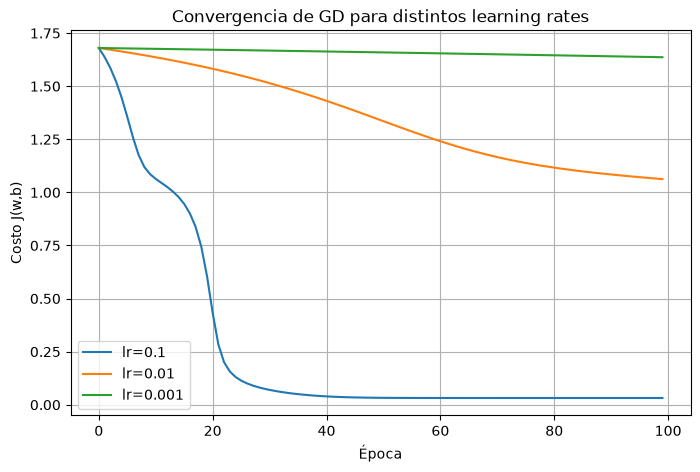

In [10]:
plt.figure(figsize=(8, 5))

for lr in learning_rates:
    plt.plot(resultados_extra[lr]["hist"], label=f"lr={lr}")

plt.xlabel("Época")
plt.ylabel("Costo J(w,b)")
plt.title("Convergencia de GD para distintos learning rates")
plt.legend()
plt.grid(True)
plt.show()

## 1. B


### Funciones implementadas

Se implementaron dos variantes de Adam:

- **Full-batch:** utiliza todos los datos para calcular cada actualización.
- **Mini-batch:** divide los datos en grupos de 32 observaciones y actualiza los parámetros varias veces por época.

La función `adam_update()` concentra el cálculo común de Adam para evitar repetir la misma lógica al actualizar \(w\) y \(b\).


In [11]:

# Actualiza el parametro elegido usando el optimizador Adam. 
# Devuelve el nuevo valor del parametro, asi como los valores actualizados de m y v.
# Donde m es la "memoria" del gradiente y v es la "memoria" del gradiente al cuadrado.
# t es el contador de actualizaciones, lr es el learning rate, 
# beta1 y beta2 son los hiperparametros de Adam 
# y eps es un valor pequeño para evitar division por cero.
# Con beta1 y beta2 cercanos a 1, se le da mas peso a los gradientes pasados.

def adam_update(param, grad, m, v, t, lr, beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1 - beta1) * grad
    v = beta2 * v + (1 - beta2) * (grad ** 2)

    m_corr = m / (1 - beta1 ** t)
    v_corr = v / (1 - beta2 ** t)

    param = param - lr * m_corr / (np.sqrt(v_corr) + eps)

    return param, m, v

# Con full-batch, se calcula el gradiente usando todos los datos de entrenamiento en cada epoca
# mv, vw, mb y vb son las memorias de los gradientes
# t sirve para contar cuantas veces se ha actualizado el modelo
# al ser full-batch, t coincide con el numero de epocas, ya que se actualiza una vez por epoca

def entrenar_adam_full_batch(x, y, lr, epocas, w0, b0):
    w = w0
    b = b0

    mw = 0
    vw = 0
    mb = 0
    vb = 0

    historial = []
    t = 0

    for _ in range(epocas):
        y_pred = modelo(x, w, b)
        j = costo(y_pred, y)
        historial.append(j)

        dw, db = gradientes(x, y, y_pred)

        t += 1

        w, mw, vw = adam_update(w, dw, mw, vw, t, lr)
        b, mb, vb = adam_update(b, db, mb, vb, t, lr)

    return w, b, historial

# Con mini-batch, se calcula el gradiente usando un subconjunto de los datos de entrenamiento en cada epoca
# Cada grupo calcula un gradiente y actualiza los pesos y el sesgo
# En este caso, hay varias actualizaciones por epoca
# n es la cantidad de datos de entrenamiento y batch_size es el tamaño del grupo de datos
# con np.random.permutation se mezclan los datos de entrenamiento para que cada grupo sea diferente en cada epoca

def entrenar_adam_minibatch(x, y, lr, epocas, w0, b0, batch_size=32):
    w = w0
    b = b0

    mw = 0
    vw = 0
    mb = 0
    vb = 0

    historial = []
    t = 0
    n = len(x)

    for _ in range(epocas):
        indices = np.random.permutation(n)
        x_shuffled = x[indices]
        y_shuffled = y[indices]

        for start in range(0, n, batch_size):
            end = start + batch_size

            xb = x_shuffled[start:end]
            yb = y_shuffled[start:end]

            y_pred_b = modelo(xb, w, b)
            dw, db = gradientes(xb, yb, y_pred_b)

            t += 1

            w, mw, vw = adam_update(w, dw, mw, vw, t, lr)
            b, mb, vb = adam_update(b, db, mb, vb, t, lr)

        y_pred = modelo(x, w, b)
        j = costo(y_pred, y)
        historial.append(j)

    return w, b, historial

### Entrenamiento

Ambas variantes de Adam se entrenan con los mismos learning rates, cantidad de épocas e inicialización utilizados con GD. Se guardan los parámetros finales y el historial de costo para comparar los tres métodos bajo las mismas condiciones generales.

La comparación se hace por cantidad de épocas. Por eso Adam mini-batch realiza más actualizaciones totales que las variantes full-batch.


In [12]:
resultados_adam_full = {}
resultados_adam_mb = {}

batch_size = 32

for lr in learning_rates:
    w_full, b_full, hist_full = entrenar_adam_full_batch(
        x, y, lr, epocas, w0, b0
    )

    resultados_adam_full[lr] = {
        "w": w_full,
        "b": b_full,
        "hist": hist_full
    }

    w_mb, b_mb, hist_mb = entrenar_adam_minibatch(
        x, y, lr, epocas, w0, b0, batch_size=batch_size
    )

    resultados_adam_mb[lr] = {
        "w": w_mb,
        "b": b_mb,
        "hist": hist_mb
    }

    print(f"\nlr = {lr}")
    print("Costo final full:", round(hist_full[-1], 6))
    print("Costo final mini:", round(hist_mb[-1], 6))


lr = 0.1
Costo final full: 0.00303
Costo final mini: 0.003307

lr = 0.01
Costo final full: 0.889039
Costo final mini: 0.002813

lr = 0.001
Costo final full: 1.302832
Costo final mini: 0.784825


### Resultados


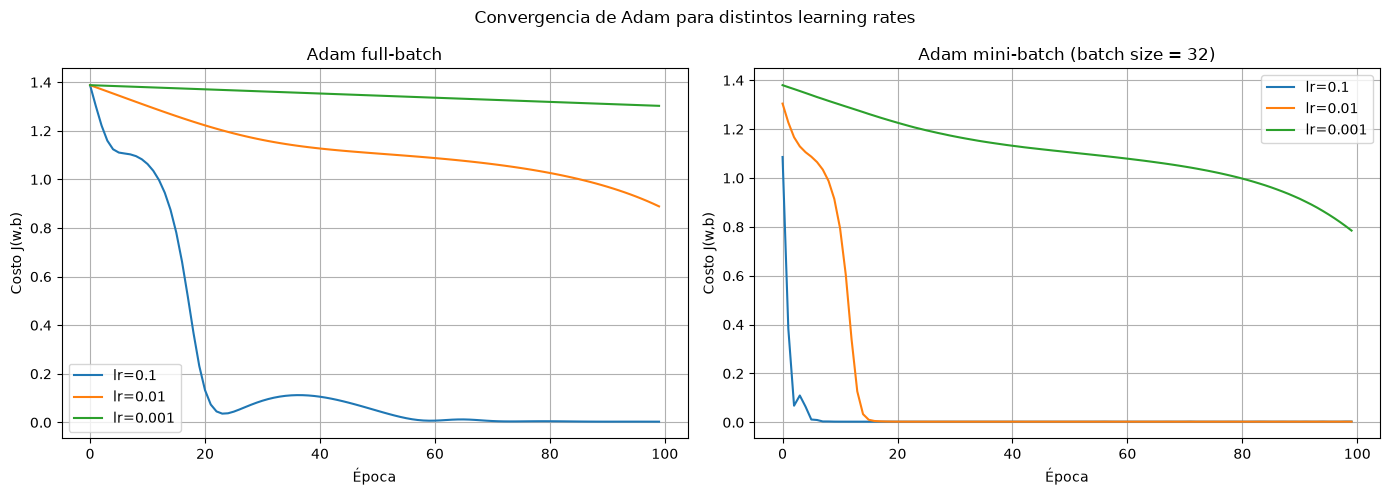

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr in learning_rates:
    axes[0].plot(resultados_adam_full[lr]["hist"], label=f"lr={lr}")

axes[0].set_title("Adam full-batch")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Costo J(w,b)")
axes[0].legend()
axes[0].grid(True)

for lr in learning_rates:
    axes[1].plot(resultados_adam_mb[lr]["hist"], label=f"lr={lr}")

axes[1].set_title(f"Adam mini-batch (batch size = {batch_size})")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Costo J(w,b)")
axes[1].legend()
axes[1].grid(True)

plt.suptitle("Convergencia de Adam para distintos learning rates")
plt.tight_layout()
plt.show()

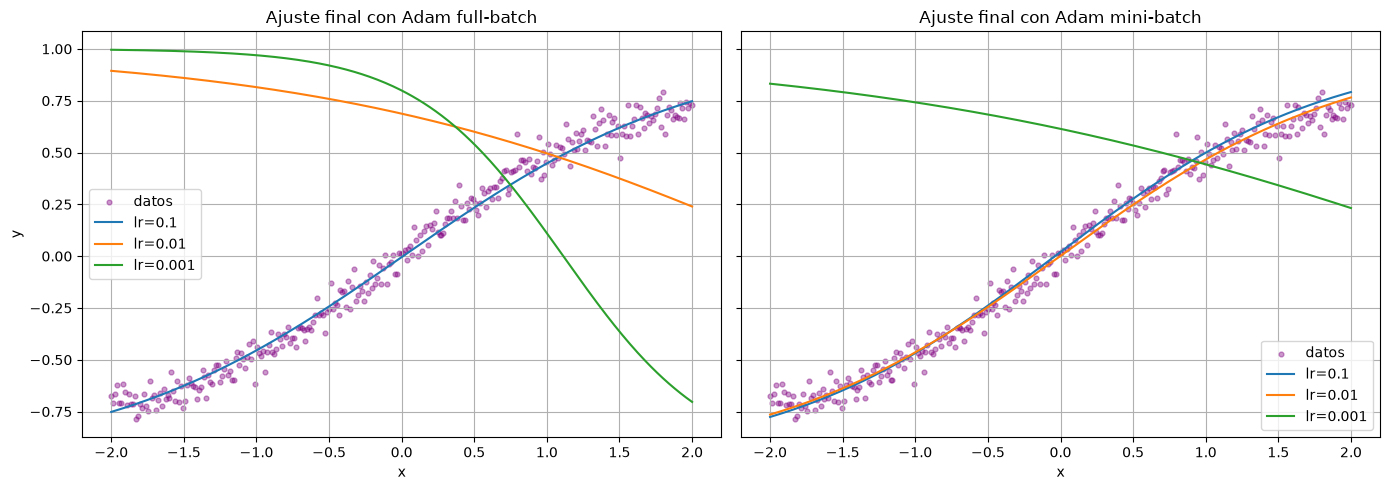

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Adam full-batch
axes[0].scatter(x, y, s=12, alpha=0.4, color="purple", label="datos")

for lr in learning_rates:
    w = resultados_adam_full[lr]["w"]
    b = resultados_adam_full[lr]["b"]
    y_pred = modelo(x, w, b)
    axes[0].plot(x, y_pred, label=f"lr={lr}")

axes[0].set_title("Ajuste final con Adam full-batch")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(True)


# Adam mini-batch
axes[1].scatter(x, y, s=12, alpha=0.4, color="purple", label="datos")

for lr in learning_rates:
    w = resultados_adam_mb[lr]["w"]
    b = resultados_adam_mb[lr]["b"]
    y_pred = modelo(x, w, b)
    axes[1].plot(x, y_pred, label=f"lr={lr}")

axes[1].set_title(f"Ajuste final con Adam mini-batch")
axes[1].set_xlabel("x")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 1. C


### Tabla comparativa


In [15]:
import pandas as pd

filas = []

for lr in learning_rates:
    filas.append({
        "learning_rate": lr,
        "optimizador": "GD",
        "w_final": resultados[lr]["w"],
        "b_final": resultados[lr]["b"],
        "costo_final": resultados[lr]["hist"][-1]
    })

    filas.append({
        "learning_rate": lr,
        "optimizador": "Adam full-batch",
        "w_final": resultados_adam_full[lr]["w"],
        "b_final": resultados_adam_full[lr]["b"],
        "costo_final": resultados_adam_full[lr]["hist"][-1]
    })

    filas.append({
        "learning_rate": lr,
        "optimizador": "Adam mini-batch",
        "w_final": resultados_adam_mb[lr]["w"],
        "b_final": resultados_adam_mb[lr]["b"],
        "costo_final": resultados_adam_mb[lr]["hist"][-1]
    })

tabla_comparativa = pd.DataFrame(filas)

tabla_comparativa

,learning_rate,optimizador,w_final,b_final,costo_final
0,0.100,GD,0.503895,0.000529,0.002813
1,0.100,Adam full-batch,0.485979,-0.004639,0.003030
2,0.100,Adam mini-batch,0.527781,0.020467,0.003307
3,0.010,GD,-0.517612,1.071489,1.040556
4,0.010,Adam full-batch,-0.299458,0.843159,0.889039
5,0.010,Adam mini-batch,0.504021,0.001389,0.002813
6,0.001,GD,-1.021536,1.019355,1.342437
7,0.001,Adam full-batch,-0.985137,1.096382,1.302832
8,0.001,Adam mini-batch,-0.239621,0.715548,0.784825


In [16]:
tabla_ranking = tabla_comparativa.sort_values(
    ["learning_rate", "costo_final"]
).reset_index(drop=True)

tabla_ranking

,learning_rate,optimizador,w_final,b_final,costo_final
0,0.001,Adam mini-batch,-0.239621,0.715548,0.784825
1,0.001,Adam full-batch,-0.985137,1.096382,1.302832
2,0.001,GD,-1.021536,1.019355,1.342437
3,0.010,Adam mini-batch,0.504021,0.001389,0.002813
4,0.010,Adam full-batch,-0.299458,0.843159,0.889039
5,0.010,GD,-0.517612,1.071489,1.040556
6,0.100,GD,0.503895,0.000529,0.002813
7,0.100,Adam full-batch,0.485979,-0.004639,0.003030
8,0.100,Adam mini-batch,0.527781,0.020467,0.003307


### Comparación gráfica


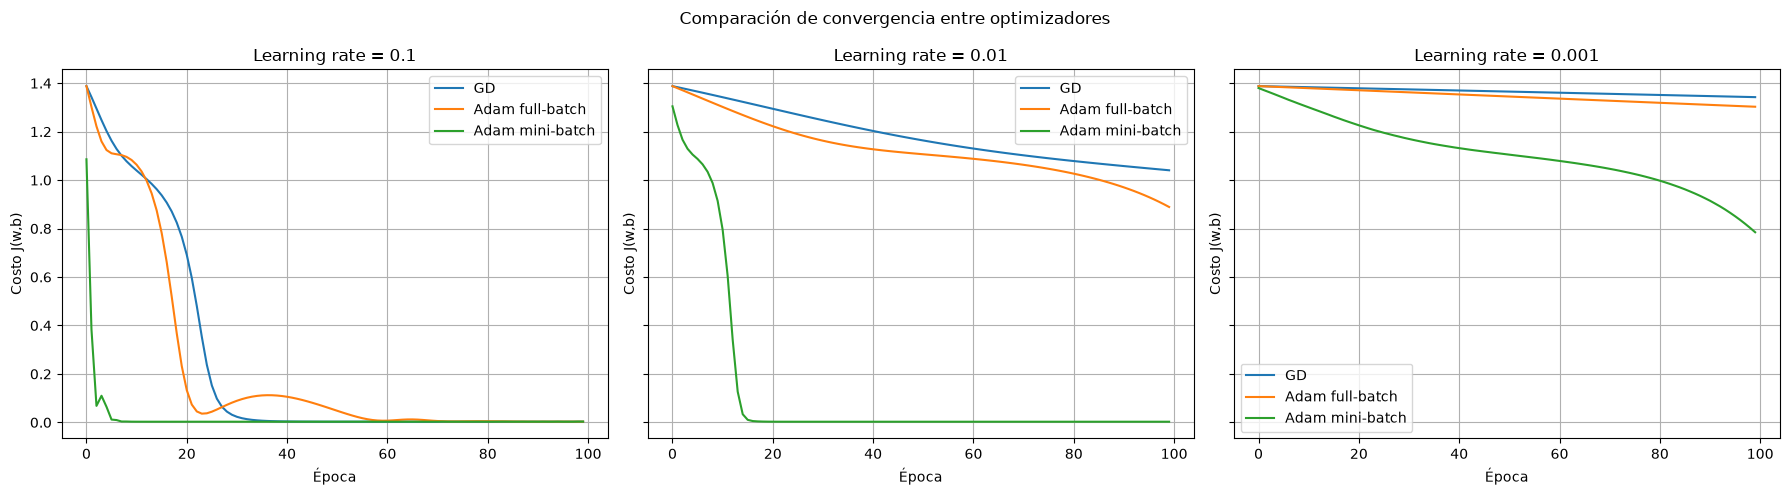

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, lr in enumerate(learning_rates):
    ax = axes[i]

    ax.plot(resultados[lr]["hist"], label="GD")
    ax.plot(resultados_adam_full[lr]["hist"], label="Adam full-batch")
    ax.plot(resultados_adam_mb[lr]["hist"], label="Adam mini-batch")

    ax.set_title(f"Learning rate = {lr}")
    ax.set_xlabel("Época")
    ax.set_ylabel("Costo J(w,b)")
    ax.grid(True)
    ax.legend()

plt.suptitle("Comparación de convergencia entre optimizadores")
plt.tight_layout()
plt.show()

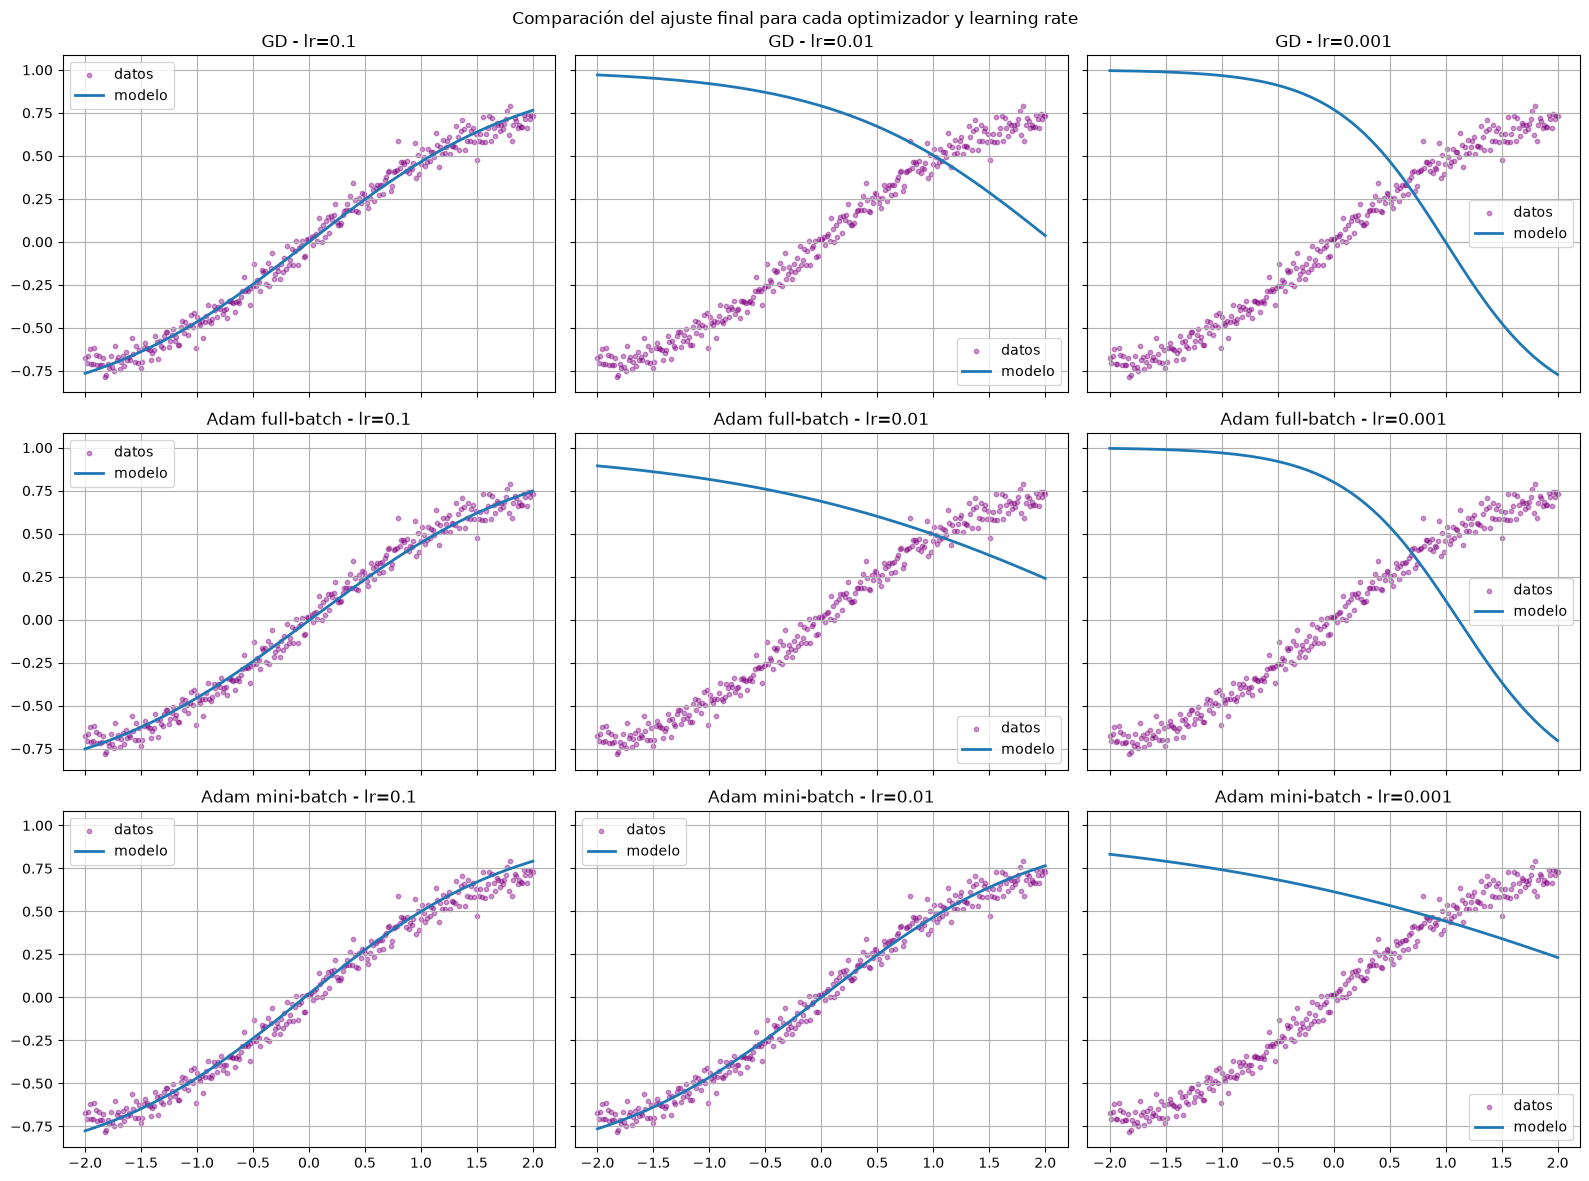

In [18]:
optimizadores = {
    "GD": resultados,
    "Adam full-batch": resultados_adam_full,
    "Adam mini-batch": resultados_adam_mb
}

fig, axes = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

for row, (nombre_opt, res_opt) in enumerate(optimizadores.items()):
    for col, lr in enumerate(learning_rates):
        ax = axes[row, col]

        w = res_opt[lr]["w"]
        b = res_opt[lr]["b"]
        y_pred = modelo(x, w, b)

        ax.scatter(x, y, s=10, alpha=0.4, color="purple", label="datos")
        ax.plot(x, y_pred, linewidth=2, label="modelo")

        ax.set_title(f"{nombre_opt} - lr={lr}")
        ax.grid(True)
        ax.legend()

plt.suptitle("Comparación del ajuste final para cada optimizador y learning rate")
plt.tight_layout()
plt.show()

### Conclusiones de la comparación

El learning rate tuvo un efecto claro sobre los tres métodos. Con `lr = 0.1`, todos llegaron a una solución de bajo costo. GD obtuvo el menor valor final, aunque las diferencias con las dos variantes de Adam fueron pequeñas.

Con `lr = 0.01`, Adam mini-batch fue el único que alcanzó un ajuste similar al obtenido con `lr = 0.1`. GD y Adam full-batch avanzaron más lentamente y, después de 100 épocas, todavía se encontraban lejos de la región de menor costo.

Con `lr = 0.001`, el paso resultó demasiado pequeño para el número de épocas utilizado. Adam mini-batch mostró una mejora mayor que los otros métodos, pero tampoco llegó a un ajuste satisfactorio.

En estas pruebas, Adam mini-batch fue el método más robusto frente a learning rates más bajos. Parte de esa ventaja se explica porque realiza varias actualizaciones por época, mientras que GD y Adam full-batch realizan una sola. Por lo tanto, la comparación refleja tanto el comportamiento del optimizador como la cantidad de actualizaciones realizadas.

El modelo es simple y cuenta con una única activación `tanh`, por lo que el objetivo no es reproducir cada punto con ruido, sino aproximar correctamente la tendencia general de los datos.


## 1. D


### Funciones con trayectoria y entrenamiento con `lr = 0.01`

Para visualizar el recorrido sobre la superficie de costo se reutilizaron los tres entrenamientos, agregando el registro de \(w\) y \(b\) después de cada actualización. Se eligió `lr = 0.01` porque permite ver una diferencia clara entre las trayectorias.


In [19]:
def entrenar_gd_trayectoria(x, y, lr, epocas, w0, b0):
    w = w0
    b = b0

    historial = []
    trayectoria = [(w, b)]

    for _ in range(epocas):
        y_pred = modelo(x, w, b)
        j = costo(y_pred, y)
        historial.append(j)

        dw, db = gradientes(x, y, y_pred)

        w -= lr * dw
        b -= lr * db

        trayectoria.append((w, b))

    return w, b, historial, np.array(trayectoria)

def entrenar_adam_full_batch_trayectoria(x, y, lr, epocas, w0, b0):
    w = w0
    b = b0

    mw = 0
    vw = 0
    mb = 0
    vb = 0

    historial = []
    trayectoria = [(w, b)]
    t = 0

    for _ in range(epocas):
        y_pred = modelo(x, w, b)
        j = costo(y_pred, y)
        historial.append(j)

        dw, db = gradientes(x, y, y_pred)

        t += 1

        w, mw, vw = adam_update(w, dw, mw, vw, t, lr)
        b, mb, vb = adam_update(b, db, mb, vb, t, lr)

        trayectoria.append((w, b))

    return w, b, historial, np.array(trayectoria)

def entrenar_adam_minibatch_trayectoria(x, y, lr, epocas, w0, b0, batch_size=32):
    w = w0
    b = b0

    mw = 0
    vw = 0
    mb = 0
    vb = 0

    historial = []
    trayectoria = [(w, b)]

    t = 0
    n = len(x)

    for _ in range(epocas):
        indices = np.random.permutation(n)
        x_shuffled = x[indices]
        y_shuffled = y[indices]

        for start in range(0, n, batch_size):
            end = start + batch_size

            xb = x_shuffled[start:end]
            yb = y_shuffled[start:end]

            y_pred_b = modelo(xb, w, b)
            dw, db = gradientes(xb, yb, y_pred_b)

            t += 1

            w, mw, vw = adam_update(w, dw, mw, vw, t, lr)
            b, mb, vb = adam_update(b, db, mb, vb, t, lr)

        y_pred = modelo(x, w, b)
        j = costo(y_pred, y)
        historial.append(j)

        trayectoria.append((w, b))

    return w, b, historial, np.array(trayectoria)

In [20]:
lr_3d = 0.01
batch_size = 32

w_gd, b_gd, hist_gd, tray_gd = entrenar_gd_trayectoria(
    x, y, lr_3d, epocas, w0, b0
)

w_af, b_af, hist_af, tray_af = entrenar_adam_full_batch_trayectoria(
    x, y, lr_3d, epocas, w0, b0
)

w_mb, b_mb, hist_mb, tray_mb = entrenar_adam_minibatch_trayectoria(
    x, y, lr_3d, epocas, w0, b0, batch_size=batch_size
)

In [21]:
w_min = min(tray_gd[:, 0].min(), tray_af[:, 0].min(), tray_mb[:, 0].min()) - 0.5
w_max = max(tray_gd[:, 0].max(), tray_af[:, 0].max(), tray_mb[:, 0].max()) + 0.5
b_min = min(tray_gd[:, 1].min(), tray_af[:, 1].min(), tray_mb[:, 1].min()) - 0.5
b_max = max(tray_gd[:, 1].max(), tray_af[:, 1].max(), tray_mb[:, 1].max()) + 0.5

w_vals = np.linspace(w_min, w_max, 80)
b_vals = np.linspace(b_min, b_max, 80)
W, B = np.meshgrid(w_vals, b_vals)

# Costo para cada combinación de w y b
pred_surface = np.tanh(W[..., None] * x + B[..., None])
J = np.mean((pred_surface - y) ** 2, axis=2)


In [22]:
def costos_trayectoria(trayectoria, x, y):
    return np.array([
        costo(modelo(x, w, b), y)
        for w, b in trayectoria
    ])

J_gd = costos_trayectoria(tray_gd, x, y)
J_af = costos_trayectoria(tray_af, x, y)
J_mb = costos_trayectoria(tray_mb, x, y)


### Gráficos


In [23]:
from matplotlib import animation
from IPython.display import HTML

path_gd_w, path_gd_b = tray_gd[:, 0], tray_gd[:, 1]
path_af_w, path_af_b = tray_af[:, 0], tray_af[:, 1]
path_mb_w, path_mb_b = tray_mb[:, 0], tray_mb[:, 1]


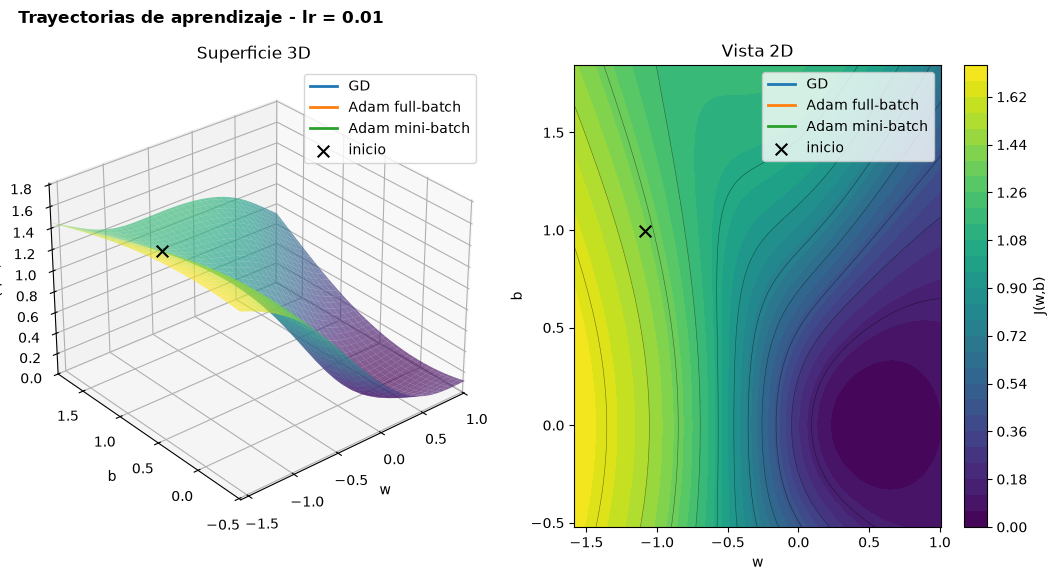

In [24]:
fig = plt.figure(figsize=(13, 6))

ax3d = fig.add_subplot(1, 2, 1, projection="3d")
ax2d = fig.add_subplot(1, 2, 2)

# Superficie 3D
ax3d.plot_surface(
    W, B, J,
    alpha=0.65,
    linewidth=0,
    antialiased=True,
    cmap="viridis"
)

ax3d.set_xlabel("w")
ax3d.set_ylabel("b")
ax3d.set_zlabel("J(w,b)")
ax3d.set_title("Superficie 3D")
ax3d.view_init(elev=30, azim=230)

ax3d.set_xlim(w_min, w_max)
ax3d.set_ylim(b_min, b_max)
ax3d.set_zlim(0, J.max() * 1.05)

# Contorno 2D
cs = ax2d.contourf(W, B, J, levels=30, cmap="viridis")
ax2d.contour(W, B, J, levels=15, colors="k", linewidths=0.4, alpha=0.5)

ax2d.set_xlabel("w")
ax2d.set_ylabel("b")
ax2d.set_title("Vista 2D")
ax2d.set_xlim(w_min, w_max)
ax2d.set_ylim(b_min, b_max)

fig.colorbar(cs, ax=ax2d, label="J(w,b)")

# Líneas 3D vacías
line_gd_3d, = ax3d.plot([], [], [], lw=2, label="GD")
line_af_3d, = ax3d.plot([], [], [], lw=2, label="Adam full-batch")
line_mb_3d, = ax3d.plot([], [], [], lw=2, label="Adam mini-batch")

# Puntos 3D
point_gd_3d = ax3d.scatter([], [], [], s=50)
point_af_3d = ax3d.scatter([], [], [], s=50)
point_mb_3d = ax3d.scatter([], [], [], s=50)

# Líneas 2D vacías
line_gd_2d, = ax2d.plot([], [], lw=2, label="GD")
line_af_2d, = ax2d.plot([], [], lw=2, label="Adam full-batch")
line_mb_2d, = ax2d.plot([], [], lw=2, label="Adam mini-batch")

# Puntos 2D
point_gd_2d, = ax2d.plot([], [], marker="o", markersize=5)
point_af_2d, = ax2d.plot([], [], marker="o", markersize=5)
point_mb_2d, = ax2d.plot([], [], marker="o", markersize=5)

# Punto inicial común
J_inicio = costo(modelo(x, w0, b0), y)

ax3d.scatter([w0], [b0], [J_inicio], s=70, c="black", marker="x", label="inicio")
ax2d.scatter([w0], [b0], s=70, c="black", marker="x", label="inicio")

ax3d.legend()
ax2d.legend()

info_text = fig.text(
    0.12, 0.95,
    f"Trayectorias de aprendizaje - lr = {lr_3d}",
    fontsize=12,
    weight="bold"
)

cost_text = fig.text(0.12, 0.91, "", fontsize=10)

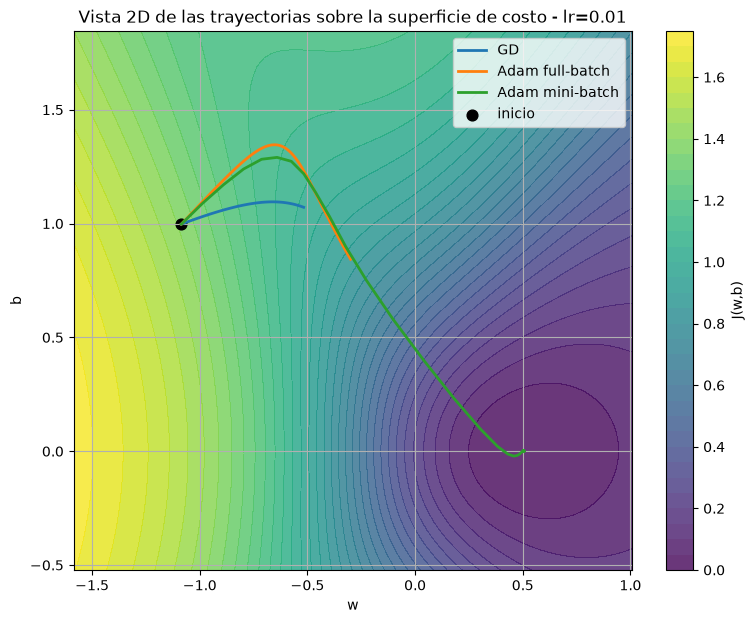

In [25]:
plt.figure(figsize=(9, 7))

plt.contourf(W, B, J, levels=40, cmap="viridis", alpha=0.8)
plt.colorbar(label="J(w,b)")

plt.plot(tray_gd[:, 0], tray_gd[:, 1], label="GD", linewidth=2)
plt.plot(tray_af[:, 0], tray_af[:, 1], label="Adam full-batch", linewidth=2)
plt.plot(tray_mb[:, 0], tray_mb[:, 1], label="Adam mini-batch", linewidth=2)

plt.scatter(w0, b0, color="black", s=60, label="inicio")

plt.xlabel("w")
plt.ylabel("b")
plt.title(f"Vista 2D de las trayectorias sobre la superficie de costo - lr={lr_3d}")
plt.legend()
plt.grid(True)
plt.show()

### Conclusión de la visualización de trayectorias

Con `lr = 0.01`, los tres métodos parten del mismo punto, pero recorren la superficie de costo de manera diferente.

GD se desplaza lentamente y permanece en una región de costo alto. Adam full-batch avanza algo más, aunque tampoco alcanza la zona del mínimo dentro de las 100 épocas. Adam mini-batch, en cambio, llega rápidamente a una región de bajo costo.

La visualización coincide con los resultados numéricos anteriores. En esta configuración, Adam mini-batch converge más rápido porque actualiza los parámetros varias veces por época. Por eso su trayectoria no solo depende de las reglas de Adam, sino también de que realiza una cantidad mayor de actualizaciones.


# Pregunta 2


## 2. A


### Carga del dataset y escaneo inicial


In [26]:
import seaborn as sns

df = pd.read_csv("dataset_compras.csv")

df.head()

,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


In [27]:
df.shape

(182721, 11)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  str    
 2   Age                         182721 non-null  str    
 3   Gender                      182721 non-null  str    
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  str    
 6   Stay_In_Current_City_Years  182721 non-null  str    
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Product_Subcategory_2       77461 non-null   float64
 10  Purchase                    182721 non-null  int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 15.3 MB


In [29]:
df.describe(include="all")

,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
count,1.827210e+05,182721,182721,182721,182721.000000,182721,182721,182721.000000,140903.000000,77461.000000,182721.000000
unique,NaN,2455,7,2,NaN,3,5,NaN,NaN,NaN,NaN
top,NaN,P00047292,46-50,M,NaN,A,1,NaN,NaN,NaN,NaN
freq,NaN,220,38173,98647,NaN,76169,41481,NaN,NaN,NaN,NaN
mean,1.050060e+06,NaN,NaN,NaN,0.647567,NaN,NaN,10.629123,24.557724,12.843483,7851.668971
std,2.884040e+04,NaN,NaN,NaN,0.477729,NaN,NaN,5.659703,12.550279,4.593955,8321.461408
min,1.000035e+06,NaN,NaN,NaN,0.000000,NaN,NaN,1.000000,3.000000,5.000000,45.000000
25%,1.024971e+06,NaN,NaN,NaN,0.000000,NaN,NaN,5.000000,13.000000,9.000000,578.000000
50%,1.050146e+06,NaN,NaN,NaN,1.000000,NaN,NaN,11.000000,24.000000,13.000000,5060.000000
75%,1.074883e+06,NaN,NaN,NaN,1.000000,NaN,NaN,16.000000,36.000000,17.000000,11930.000000


In [30]:
df.isna().sum().sort_values(ascending=False)

Product_Subcategory_2         105260
Product_Subcategory_1          41818
User_ID                            0
Age                                0
Product_ID                         0
Gender                             0
Marital_Status                     0
Stay_In_Current_City_Years         0
City_Category                      0
Product_Category                   0
Purchase                           0
dtype: int64

### EDA


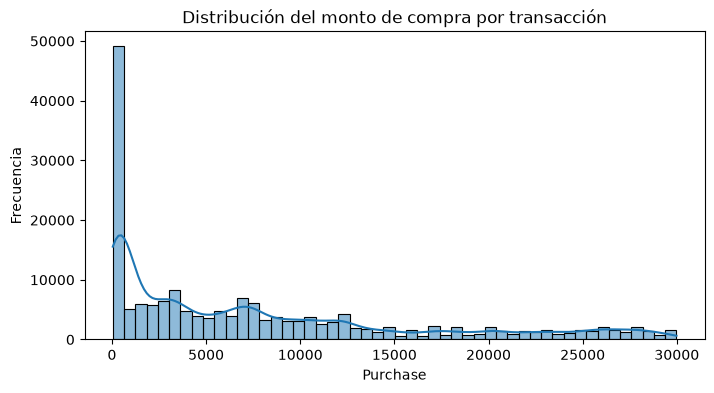

In [31]:
plt.figure(figsize=(8,4))
sns.histplot(df["Purchase"], bins=50, kde=True)
plt.title("Distribución del monto de compra por transacción")
plt.xlabel("Purchase")
plt.ylabel("Frecuencia")
plt.show()

In [32]:
purchases_per_user = df.groupby("User_ID").size()

purchases_per_user.describe()

count    7432.000000
mean       24.585710
std        13.686571
min        10.000000
25%        14.000000
50%        18.000000
75%        40.000000
max        50.000000
dtype: float64

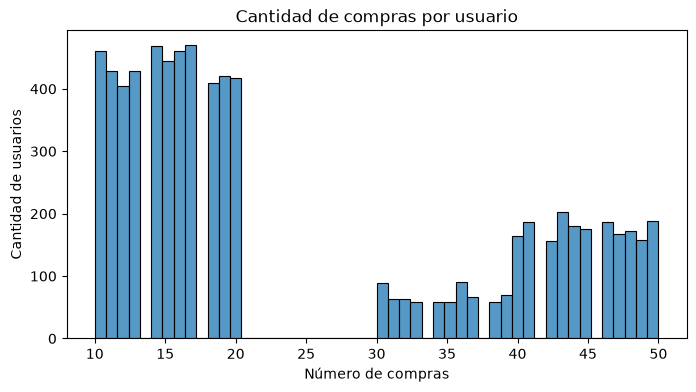

In [33]:
plt.figure(figsize=(8,4))
sns.histplot(purchases_per_user, bins=50)
plt.title("Cantidad de compras por usuario")
plt.xlabel("Número de compras")
plt.ylabel("Cantidad de usuarios")
plt.show()

In [34]:
user_avg_purchase = df.groupby("User_ID")["Purchase"].mean()

user_avg_purchase.describe()

count     7432.000000
mean      6749.655185
std       3297.891670
min        275.272727
25%       4247.395833
50%       6330.212766
75%       8519.184470
max      17231.138889
Name: Purchase, dtype: float64

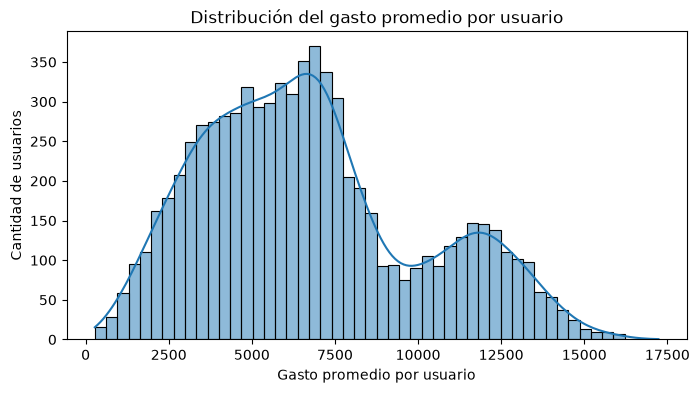

In [35]:
plt.figure(figsize=(8,4))
sns.histplot(user_avg_purchase, bins=50, kde=True)
plt.title("Distribución del gasto promedio por usuario")
plt.xlabel("Gasto promedio por usuario")
plt.ylabel("Cantidad de usuarios")
plt.show()

In [36]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing

Product_Subcategory_2         57.606953
Product_Subcategory_1         22.886258
User_ID                        0.000000
Age                            0.000000
Product_ID                     0.000000
Gender                         0.000000
Marital_Status                 0.000000
Stay_In_Current_City_Years     0.000000
City_Category                  0.000000
Product_Category               0.000000
Purchase                       0.000000
dtype: float64

### Tratamiento y construcción del dataset por usuario

Las dos subcategorías presentan valores faltantes. En lugar de eliminar esas columnas, los nulos se reemplazan por `"Unknown"`, ya que la ausencia de subcategoría también puede aportar información.

A partir de la aclaración del docente, el escenario de clientes con pocas compras se interpreta como un posible uso futuro del modelo y no como una indicación para conservar solo cinco transacciones. Por eso, para construir una fila por usuario se utilizan todas las compras disponibles.

Se evitan variables como la cantidad total de compras, la cantidad de productos distintos o la cantidad de categorías distintas, porque dependen directamente del historial acumulado del cliente. En cambio, se conservan variables demográficas, preferencias de compra y medidas de dispersión que describen el comportamiento sin indicar cuántas transacciones realizó cada usuario.


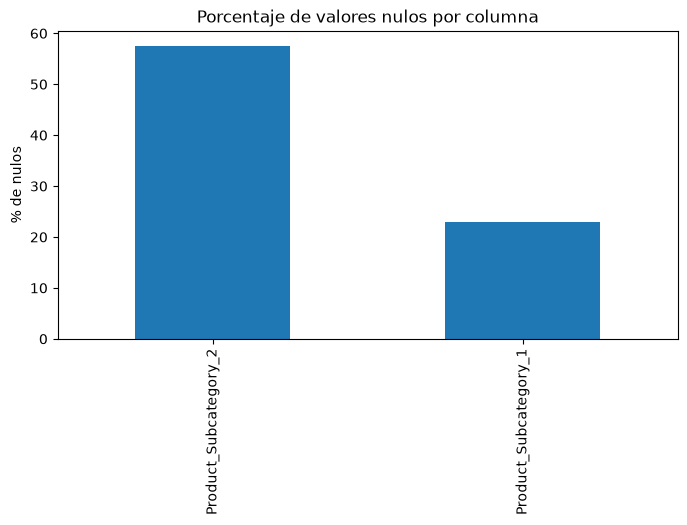

In [37]:
plt.figure(figsize=(8,4))
missing[missing > 0].plot(kind="bar")
plt.title("Porcentaje de valores nulos por columna")
plt.ylabel("% de nulos")
plt.show()

In [38]:
for col in ["Product_Subcategory_1", "Product_Subcategory_2"]:
    df[col] = df[col].fillna("Unknown")

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from copy import deepcopy
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


In [40]:
def safe_mode(series):
    modes = series.mode(dropna=True)
    return modes.iloc[0] if not modes.empty else "Unknown"


# Se utilizan todas las compras disponibles de cada usuario
user_df = (
    df.groupby("User_ID")
      .agg(
          Gender=("Gender", "first"),
          Age=("Age", "first"),
          City_Category=("City_Category", "first"),
          Stay_In_Current_City_Years=("Stay_In_Current_City_Years", "first"),
          Marital_Status=("Marital_Status", "first"),
          Favorite_Product=("Product_ID", safe_mode),
          Favorite_Category=("Product_Category", safe_mode),
          Favorite_Subcategory_1=("Product_Subcategory_1", safe_mode),
          Favorite_Subcategory_2=("Product_Subcategory_2", safe_mode),
          Purchase_Std=("Purchase", "std"),
          Purchase_Avg=("Purchase", "mean")
      )
      .reset_index(drop=True)
)

# Un usuario con una sola compra no tendría desvío estándar
user_df["Purchase_Std"] = user_df["Purchase_Std"].fillna(0)

print("Dimensiones del dataset por usuario:", user_df.shape)
user_df.head()


Dimensiones del dataset por usuario: (7432, 11)


,Gender,Age,City_Category,Stay_In_Current_City_Years,Marital_Status,Favorite_Product,Favorite_Category,Favorite_Subcategory_1,Favorite_Subcategory_2,Purchase_Std,Purchase_Avg
0,M,18-25,A,1,0,P00009330,16,4.0,Unknown,3556.599417,1912.923077
1,M,36-45,A,4,1,P00000337,18,Unknown,Unknown,8955.623928,14338.906977
2,M,46-50,B,4,1,P00002733,16,Unknown,Unknown,3441.523870,4120.809524
3,F,55+,C,4,1,P00063082,20,Unknown,Unknown,9335.838593,11228.219512
4,F,46-50,C,2,1,P00006469,3,Unknown,Unknown,7054.347169,4673.882353


In [41]:
print("Valores faltantes:")
display(user_df.isna().sum().sort_values(ascending=False))

print("\nCardinalidad de variables categóricas:")
categorical_features = [
    "Gender", "Age", "City_Category",
    "Stay_In_Current_City_Years", "Marital_Status",
    "Favorite_Product", "Favorite_Category",
    "Favorite_Subcategory_1", "Favorite_Subcategory_2"
]

for col in categorical_features:
    print(f"{col}: {user_df[col].nunique()} valores")


Valores faltantes:


Gender                        0
Age                           0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Favorite_Product              0
Favorite_Category             0
Favorite_Subcategory_1        0
Favorite_Subcategory_2        0
Purchase_Std                  0
Purchase_Avg                  0
dtype: int64


Cardinalidad de variables categóricas:
Gender: 2 valores
Age: 7 valores
City_Category: 3 valores
Stay_In_Current_City_Years: 5 valores
Marital_Status: 2 valores
Favorite_Product: 1214 valores
Favorite_Category: 20 valores
Favorite_Subcategory_1: 31 valores
Favorite_Subcategory_2: 14 valores


#### Conclusiones del EDA y decisiones de preparación

El dataset contiene múltiples transacciones por usuario, por lo que fue necesario agruparlo para obtener una sola fila por cliente. El target se calculó como el gasto promedio de todas las compras disponibles para cada usuario.

`User_ID` se utilizó únicamente para agrupar y no se incorporó como variable predictora. Tampoco se incluyeron variables como cantidad de compras, cantidad de productos distintos o cantidad de categorías distintas, ya que aumentarían con la antigüedad y podrían hacer que el modelo dependa del volumen de interacciones acumuladas.

Como patrones de comportamiento se conservaron el producto, la categoría y las subcategorías más frecuentes, además del desvío estándar del monto de compra. Estas variables resumen preferencias y variabilidad sin indicar directamente cuántas transacciones realizó el cliente.

Las subcategorías presentan una cantidad importante de valores faltantes. En lugar de eliminarlas, los nulos se representaron con la categoría `"Unknown"`.


#### Separación y encoding

Las variables demográficas y las categorías con pocos valores posibles se procesan mediante *one-hot encoding*. `Favorite_Product` y las dos subcategorías tienen una cardinalidad mayor, por lo que se utiliza `TargetEncoder`. `Favorite_Category` se trata como categórica aunque esté representada por números, ya que sus códigos no expresan una magnitud ni un orden.

El target es el gasto promedio calculado con todas las compras disponibles de cada usuario. Las features describen características demográficas, preferencias y variabilidad del gasto, pero no incluyen la cantidad de transacciones acumuladas.

El preprocesador se ajusta únicamente con train. Validation y test se transforman después para evitar que participen en el encoding o en el escalado.


In [42]:
# Features y target
X = user_df.drop(columns="Purchase_Avg")
y = user_df["Purchase_Avg"]

# 20% para test; del 80% restante se separa validation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.10, random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (5350, 10)
Validation: (595, 10)
Test: (1487, 10)


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler

X_train, X_val, X_test = X_train.copy(), X_val.copy(), X_test.copy()

ohe_cols = [
    "Gender", "Age", "Marital_Status", "City_Category",
    "Stay_In_Current_City_Years", "Favorite_Category"
]

target_enc_cols = [
    "Favorite_Product",
    "Favorite_Subcategory_1",
    "Favorite_Subcategory_2"
]

categorical_cols = ohe_cols + target_enc_cols
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

# Se unifica el tipo para evitar diferencias entre los conjuntos
for data in (X_train, X_val, X_test):
    data[categorical_cols] = (
        data[categorical_cols]
        .fillna("Unknown")
        .astype(str)
    )

print("One-hot encoding:", ohe_cols)
print("Target encoding:", target_enc_cols)
print("Variables numéricas:", numeric_cols)


One-hot encoding: ['Gender', 'Age', 'Marital_Status', 'City_Category', 'Stay_In_Current_City_Years', 'Favorite_Category']
Target encoding: ['Favorite_Product', 'Favorite_Subcategory_1', 'Favorite_Subcategory_2']
Variables numéricas: ['Purchase_Std']


In [44]:
preprocessor = ColumnTransformer([
    (
        "one_hot",
        OneHotEncoder(handle_unknown="ignore", sparse_output=False),
        ohe_cols
    ),
    (
        "target_encoding",
        Pipeline([
            ("encoder", TargetEncoder(random_state=42)),
            ("scaler", StandardScaler())
        ]),
        target_enc_cols
    ),
    ("numeric", StandardScaler(), numeric_cols)
])


In [45]:
X_train_processed = preprocessor.fit_transform(
    X_train,
    y_train
)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Train:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Train: (5350, 43)
Validation: (595, 43)
Test: (1487, 43)


c:\Users\tolot\anaconda3\envs\ap_deep_learning\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


In [46]:
scaler_y = StandardScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
)

y_val_scaled = scaler_y.transform(
    y_val.to_numpy().reshape(-1, 1)
)

y_test_scaled = scaler_y.transform(
    y_test.to_numpy().reshape(-1, 1)
)

## 2. B


### Tensores


In [47]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1)

In [48]:
batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### Modelo

Se utiliza una red MLP con tres capas ocultas de 64, 32 y 32 neuronas. Todas cumplen con el mínimo pedido en la consigna. Se usa ReLU después de cada capa oculta y dropout en las dos primeras para reducir el sobreajuste.


In [49]:
def build_model(input_dim, dropout_rate=0.2):
    return nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Dropout(dropout_rate),

        nn.Linear(32, 32),
        nn.ReLU(),

        nn.Linear(32, 1)
    )


In [50]:
input_dim = X_train_processed.shape[1]

model = build_model(input_dim)
print(model)

Sequential(
  (0): Linear(in_features=43, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=32, out_features=32, bias=True)
  (7): ReLU()
  (8): Linear(in_features=32, out_features=1, bias=True)
)


### Pruebas con distintos learning rates


In [51]:
epochs = 200

learning_rates = [0.01, 0.001, 0.0005, 0.0001]
lr_results = []

for lr in learning_rates:
    print(f"\nEntrenando con learning rate = {lr}")

    torch.manual_seed(42)

    # Se crea un modelo nuevo para cada learning rate
    model_lr = build_model(input_dim)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model_lr.parameters(), lr=lr)

    train_losses_lr = []
    val_losses_lr = []

    best_lr_val_loss = float("inf")
    best_lr_epoch = 0
    best_lr_state = None

    for epoch in range(epochs):
        # Entrenamiento
        model_lr.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()

            y_pred = model_lr(X_batch)
            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses_lr.append(train_loss)

        # Validación
        model_lr.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                y_pred = model_lr(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item() * X_batch.size(0)

        val_loss /= len(val_loader.dataset)
        val_losses_lr.append(val_loss)

        # Guardar los pesos correspondientes a la mejor época
        if val_loss < best_lr_val_loss:
            best_lr_val_loss = val_loss
            best_lr_epoch = epoch + 1
            best_lr_state = deepcopy(model_lr.state_dict())

    model_lr.load_state_dict(best_lr_state)

    lr_results.append({
        "learning_rate": lr,
        "best_val_loss": best_lr_val_loss,
        "best_epoch": best_lr_epoch,
        "train_losses": train_losses_lr,
        "val_losses": val_losses_lr,
        "model": model_lr
    })



Entrenando con learning rate = 0.01

Entrenando con learning rate = 0.001

Entrenando con learning rate = 0.0005

Entrenando con learning rate = 0.0001


### Comparación 


In [52]:
results_df = pd.DataFrame([
    {
        "learning_rate": r["learning_rate"],
        "best_val_loss": r["best_val_loss"],
        "best_epoch": r["best_epoch"]
    }
    for r in lr_results
]).sort_values("best_val_loss")

results_df

,learning_rate,best_val_loss,best_epoch
3,0.0001,0.120674,195
2,0.0005,0.121244,46
0,0.0100,0.121731,26
1,0.0010,0.122933,26


In [53]:
best_lr = results_df.iloc[0]["learning_rate"]

best_result = next(r for r in lr_results if r["learning_rate"] == best_lr)
best_model = best_result["model"]

print("Mejor learning rate:", best_lr)
print("Mejor época:", best_result["best_epoch"])
print("Mejor validation loss:", best_result["best_val_loss"])

Mejor learning rate: 0.0001
Mejor época: 195
Mejor validation loss: 0.12067413206110482


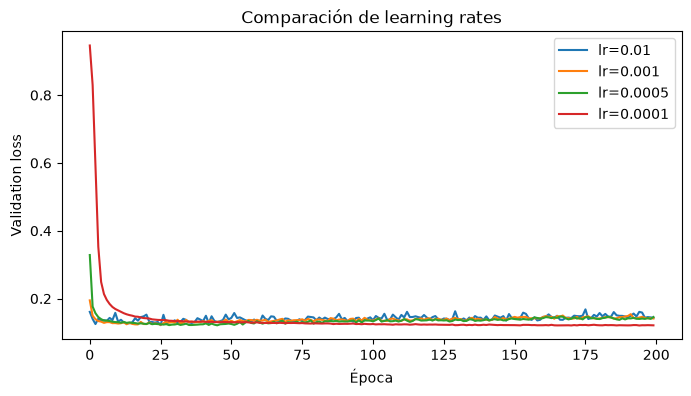

In [54]:
plt.figure(figsize=(8,4))

for r in lr_results:
    plt.plot(r["val_losses"], label=f"lr={r['learning_rate']}")

plt.xlabel("Época")
plt.ylabel("Validation loss")
plt.title("Comparación de learning rates")
plt.legend()
plt.show()

### Elección de la configuración

Se utilizó `MSELoss` como función de costo porque se trata de un problema de regresión. Además, esta función penaliza con mayor intensidad los errores grandes, lo que ayuda al modelo a corregir las predicciones más alejadas de los valores reales.

Como optimizador se eligió Adam, ya que ajusta automáticamente el paso de actualización de cada parámetro y permitió obtener un entrenamiento estable.

Para seleccionar el learning rate se compararon los valores `0.01`, `0.001`, `0.0005` y `0.0001`. En todos los casos se mantuvieron la misma arquitectura, la misma semilla y la misma cantidad máxima de épocas, para que la comparación fuera justa. Para cada valor se conservaron los pesos correspondientes a la menor pérdida obtenida en el conjunto de validation.

La configuración final se seleccionó únicamente a partir de los resultados de validation. El conjunto de test se reservó para la evaluación final, evitando utilizarlo durante la elección de los hiperparámetros.


## 2. C


### Entrenamiento


In [55]:
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            pred = model(X_batch)
            total_loss += criterion(pred, y_batch).item() * len(X_batch)
            y_true.extend(y_batch.numpy().ravel())
            y_pred.extend(pred.numpy().ravel())

    avg_loss = total_loss / len(data_loader.dataset)
    return avg_loss, r2_score(y_true, y_pred)


In [56]:
torch.manual_seed(42)

model = build_model(X_train_tensor.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

epochs = 200
patience = 10

best_val_loss = float("inf")
best_epoch = 0
best_model_state = None
epochs_without_improvement = 0

train_losses, val_losses = [], []
train_r2_history, val_r2_history = [], []


In [57]:
for epoch in range(epochs):
    model.train()

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()

    train_loss, train_r2 = evaluate_model(model, train_loader, criterion)
    val_loss, val_r2 = evaluate_model(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_r2_history.append(train_r2)
    val_r2_history.append(val_r2)

    # Se conservan los pesos de la mejor época
    if val_loss < best_val_loss - 1e-5:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_model_state = deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 20 == 0:
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f} | "
            f"Train R2: {train_r2:.4f} | Val R2: {val_r2:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping en época {epoch + 1}")
        break

model.load_state_dict(best_model_state)

print(f"Mejor época: {best_epoch}")
print(f"Mejor validation loss: {best_val_loss:.6f}")


Epoch 20/200 | Train loss: 0.1604 | Val loss: 0.1434 | Train R2: 0.8396 | Val R2: 0.8549
Epoch 40/200 | Train loss: 0.1440 | Val loss: 0.1317 | Train R2: 0.8560 | Val R2: 0.8667
Epoch 60/200 | Train loss: 0.1372 | Val loss: 0.1288 | Train R2: 0.8628 | Val R2: 0.8696
Epoch 80/200 | Train loss: 0.1321 | Val loss: 0.1269 | Train R2: 0.8679 | Val R2: 0.8716
Epoch 100/200 | Train loss: 0.1279 | Val loss: 0.1253 | Train R2: 0.8721 | Val R2: 0.8732
Epoch 120/200 | Train loss: 0.1242 | Val loss: 0.1238 | Train R2: 0.8758 | Val R2: 0.8747
Epoch 140/200 | Train loss: 0.1203 | Val loss: 0.1222 | Train R2: 0.8797 | Val R2: 0.8763
Early stopping en época 154
Mejor época: 144
Mejor validation loss: 0.121753


### Visualización y resultados


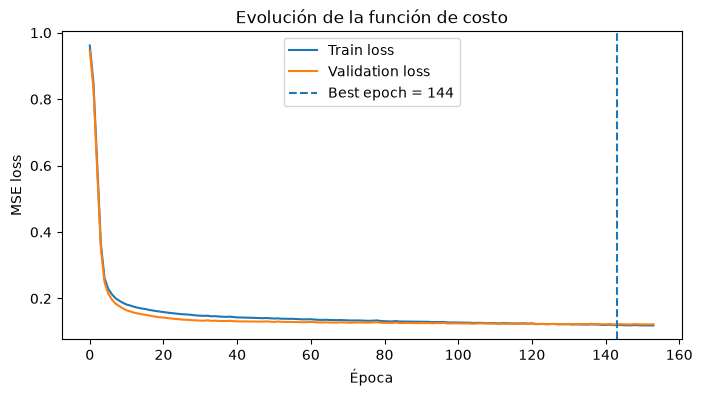

In [58]:
plt.figure(figsize=(8, 4))

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Época")
plt.ylabel("MSE loss")
plt.title("Evolución de la función de costo")
plt.legend()
plt.show()

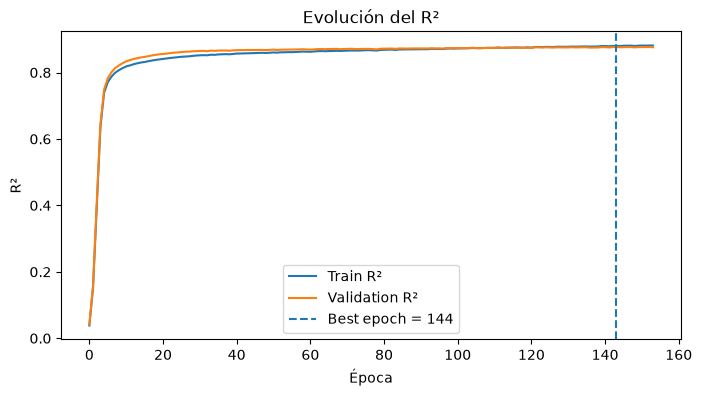

In [59]:
plt.figure(figsize=(8, 4))

plt.plot(train_r2_history, label="Train R²")
plt.plot(val_r2_history, label="Validation R²")
plt.axvline(
    best_epoch - 1,
    linestyle="--",
    label=f"Best epoch = {best_epoch}"
)

plt.xlabel("Época")
plt.ylabel("R²")
plt.title("Evolución del R²")
plt.legend()
plt.show()

In [60]:
model.eval()

with torch.no_grad():
    y_pred_val_scaled = model(X_val_tensor).numpy()

y_pred_val = scaler_y.inverse_transform(y_pred_val_scaled).ravel()
y_val_original = y_val.to_numpy()


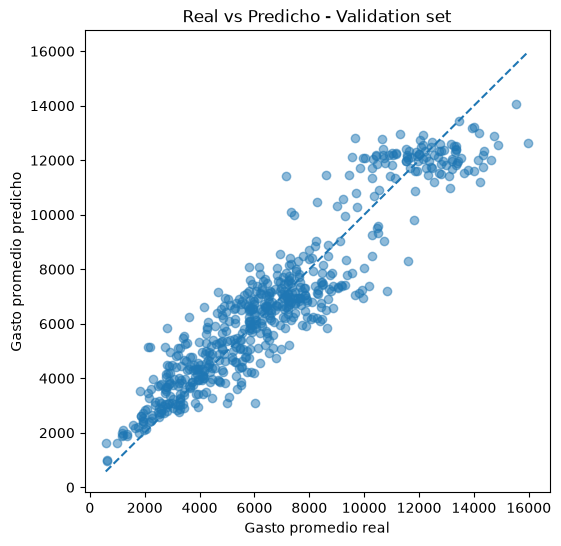

In [61]:
plt.figure(figsize=(6,6))

plt.scatter(y_val_original, y_pred_val, alpha=0.5)

plt.plot(
    [y_val_original.min(), y_val_original.max()],
    [y_val_original.min(), y_val_original.max()],
    linestyle="--"
)

plt.xlabel("Gasto promedio real")
plt.ylabel("Gasto promedio predicho")
plt.title("Real vs Predicho - Validation set")
plt.show()

In [62]:
val_mae = mean_absolute_error(y_val_original, y_pred_val)
val_rmse = np.sqrt(mean_squared_error(y_val_original, y_pred_val))
val_r2 = r2_score(y_val_original, y_pred_val)

print(f"Validation MAE: {val_mae:.2f}")
print(f"Validation RMSE: {val_rmse:.2f}")
print(f"Validation R2: {val_r2:.4f}")

Validation MAE: 905.84
Validation RMSE: 1157.08
Validation R2: 0.8768


### Evaluación del modelo

La mejor configuración se entrenó nuevamente utilizando early stopping. El entrenamiento se detuvo cuando la pérdida de validation no mejoró durante diez épocas consecutivas y, al finalizar, se restauraron los pesos correspondientes a la mejor época. Esto permitió evitar un entrenamiento innecesariamente largo y reducir el riesgo de sobreajuste.

Las curvas de pérdida y de R² permiten comparar el comportamiento del modelo en train y validation a lo largo de las épocas. Como ambas curvas mantienen una evolución similar, no se observan señales claras de sobreajuste.

En el conjunto de validation se obtuvieron los siguientes resultados:

* MAE: 905.84
* RMSE: 1157.08
* R²: 0.8768

El R² de 0.8768 indica que el modelo logra explicar aproximadamente el 88 % de la variabilidad del gasto promedio. Además, supera ampliamente el valor de referencia de 0.70 propuesto en la consigna, por lo que el objetivo puede considerarse alcanzado.

El MAE indica que, en promedio, las predicciones se alejan aproximadamente 906 unidades del valor real. El RMSE es algo mayor porque penaliza con más fuerza los errores grandes, lo que sugiere que existen algunos casos con diferencias más elevadas entre el valor real y el predicho.

Por último, el gráfico de valores reales frente a predichos permite observar que el modelo sigue la tendencia general de los datos, aunque todavía presenta cierta dispersión y algunos errores mayores en determinados casos.



### Evaluación final en test

El conjunto de test se utiliza una sola vez, después de elegir el learning rate, la arquitectura y la mejor época a partir de validation. De esta manera funciona como una estimación independiente de la capacidad de generalización del modelo.


In [63]:
# El test se evalúa una sola vez, después de elegir la configuración final
model.eval()

with torch.no_grad():
    y_pred_test_scaled = model(X_test_tensor).numpy()

y_pred_test = scaler_y.inverse_transform(y_pred_test_scaled).ravel()
y_test_original = y_test.to_numpy()

test_mae = mean_absolute_error(y_test_original, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_test))
test_r2 = r2_score(y_test_original, y_pred_test)

print(f"Test MAE: {test_mae:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R2: {test_r2:.4f}")


Test MAE: 903.44
Test RMSE: 1177.71
Test R2: 0.8670


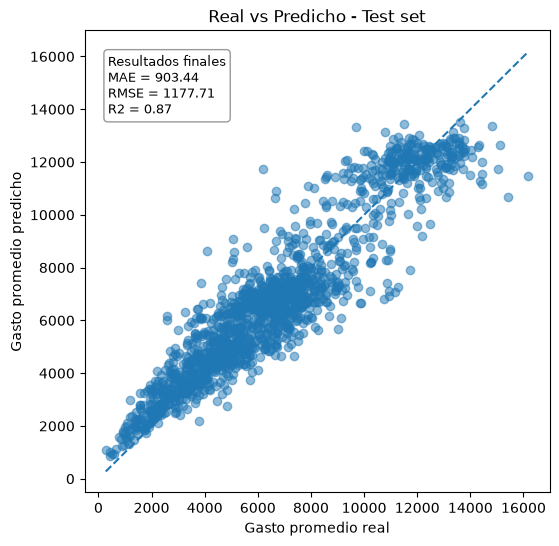

In [64]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_original, y_pred_test, alpha=0.5)

plt.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    linestyle="--"
)

plt.xlabel("Gasto promedio real")
plt.ylabel("Gasto promedio predicho")
plt.title("Real vs Predicho - Test set")

textstr = f"Resultados finales\nMAE = {test_mae:.2f}\nRMSE = {test_rmse:.2f}\nR2 = {test_r2:.2f}"
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=9.5,
            verticalalignment='top', bbox=props)


plt.show()

## 2. D


### Conclusiones finales

En esta parte del trabajo se desarrolló un modelo MLP para estimar el gasto promedio de cada cliente a partir de su información demográfica y de patrones generales obtenidos de sus compras.

El dataset original se encontraba a nivel transaccional, por lo que fue necesario agruparlo para obtener una única fila por usuario. El target se definió como el valor promedio de compra de cada cliente.

Como variables de entrada se utilizaron características demográficas, las preferencias más frecuentes de producto y categoría, y el desvío estándar del gasto. No se incluyeron variables como la cantidad total de compras, productos distintos o categorías distintas, ya que dependen del historial acumulado de cada cliente y podrían dificultar el uso del modelo con usuarios nuevos o con pocas interacciones.

Las variables categóricas de baja cardinalidad se procesaron mediante one-hot encoding, mientras que las de mayor cardinalidad se transformaron mediante target encoding. Además, las variables numéricas fueron estandarizadas. Todas estas transformaciones se ajustaron únicamente con el conjunto de train para evitar que los datos de validation o test influyeran en el preprocesamiento.

Las features utilizadas fueron:

* `Gender`: one-hot encoding.
* `Age`: one-hot encoding.
* `City_Category`: one-hot encoding.
* `Stay_In_Current_City_Years`: one-hot encoding.
* `Marital_Status`: one-hot encoding.
* `Favorite_Product`: target encoding y estandarización.
* `Favorite_Category`: target encoding y estandarización.
* `Favorite_Subcategory_1`: target encoding y estandarización.
* `Favorite_Subcategory_2`: target encoding y estandarización.
* `Purchase_Std`: estandarización.

La red final contó con tres capas ocultas de 64, 32 y 32 neuronas, activación ReLU y dropout. Se utilizó MSE como función de costo y Adam como optimizador. Tanto el learning rate como la mejor época se seleccionaron utilizando el conjunto de validation, mientras que el conjunto de test se reservó para la evaluación final.

El modelo obtuvo un R² de 0.870 en validation, por lo que logró explicar aproximadamente el 88 % de la variabilidad del gasto promedio. Este valor supera ampliamente la referencia de 0.70 indicada en la consigna, por lo que el objetivo puede considerarse cumplido.

En cuanto al error, se obtuvo un MAE cercano a 903 y un RMSE de aproximadamente 1177. Estas métricas muestran el tamaño de las diferencias entre los valores reales y los predichos. Sin embargo, para determinar si este nivel de error es aceptable desde un punto de vista práctico, sería necesario conocer mejor el contexto del problema y la escala habitual del gasto de los clientes.

En conclusión, el modelo presentó un buen desempeño general y mostró que las características demográficas y los patrones resumidos de compra permiten explicar una parte importante de las diferencias de gasto promedio entre los clientes. Aun así, sería útil analizar los errores por rangos de gasto para identificar en qué tipos de clientes el modelo presenta mayores dificultades.
